<a href="https://colab.research.google.com/github/jesplin/icpsr-pipeline/blob/main/labs/11_ocr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 11: OCR — Turning Document Images into Text

ICPSR 2026 — The Social Science Data Pipeline
Instructor: Andy Halterman


In [1]:
# Setup (this same block opens every lab this week)
import os

def is_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

IN_COLAB = is_colab()
print(f"Environment detected: {'Colab' if IN_COLAB else 'Local/hosted Jupyter'}")

if IN_COLAB:
    if not os.path.exists("/content/icpsr-pipeline"):
        !git clone -q https://github.com/ahalterman/icpsr-pipeline.git /content/icpsr-pipeline
    COURSE_DIR = "/content/icpsr-pipeline"
else:
    COURSE_DIR = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) in ("labs", "solutions") else os.getcwd()

SAMPLES_DIR = os.path.join(COURSE_DIR, "labs", "ocr_samples")
OUTPUTS_DIR = os.path.join(COURSE_DIR, "outputs")
os.makedirs(OUTPUTS_DIR, exist_ok=True)

Environment detected: Colab


## Installing Tesseract

One wrinkle: Tesseract is a *system program*, not just a Python package. The
`pytesseract` package is a thin wrapper that shells out to the `tesseract`
binary, so you have to install the binary separately.

- **Colab**: `apt-get install tesseract-ocr` (the cell below does it).
- **Mac**: `brew install tesseract`.
- **Windows/Linux**: see the Tesseract install docs, or just skip the
  Tesseract cells and use the VLM path, which needs no local binary.

In [2]:
if IN_COLAB:
    !apt-get install -qq tesseract-ocr > /dev/null
    !pip install -q pytesseract pillow openai

In [3]:
# Course helpers.
import sys
sys.path.insert(0, COURSE_DIR)

import course_utils
from course_utils import chat_image, parse_json

course_utils.LOG_PATH = os.path.join(OUTPUTS_DIR, "llm_call_log.csv")

from PIL import Image

## The sample documents

A few public-domain documents are in `labs/ocr_samples/`
 They're picked to span the range of difficulty.


- `cuban_missile.jpg` — a 21 Oct 1962 memo, "Soviet Military Build-Up in Cuba."
  A relatively clean typescript with an outline structure.
- `cuban_missile2.jpg` — an 18 Oct 1962 CIA memo on Mission 3102. A badly
  degraded photocopy with redaction bars: faint, blotchy, hard even for a human.
- `typescript_1961_letter.jpg` — a 1961 government letter, another faded
  typewritten photocopy, for a non-intel comparison.
- `printed_table_pike.jpg` — an 1870 census *printed table* of population by
  precinct, with a numeric totals row. The "extract a table from a scanned
  document" case one of you asked about.

And the harder end of the range — handwriting and historical scripts:

- `declaration_1776.jpg` — the Declaration of Independence, in ornate
  18th-century engrossed script.
- `gettysburg_handwritten.jpg` — the Gettysburg Address in Lincoln's cursive.
- `census_1940_table.jpg` — a 1940 Census population schedule: a *handwritten
  table*, the hardest case here (bad handwriting *and* a grid layout).

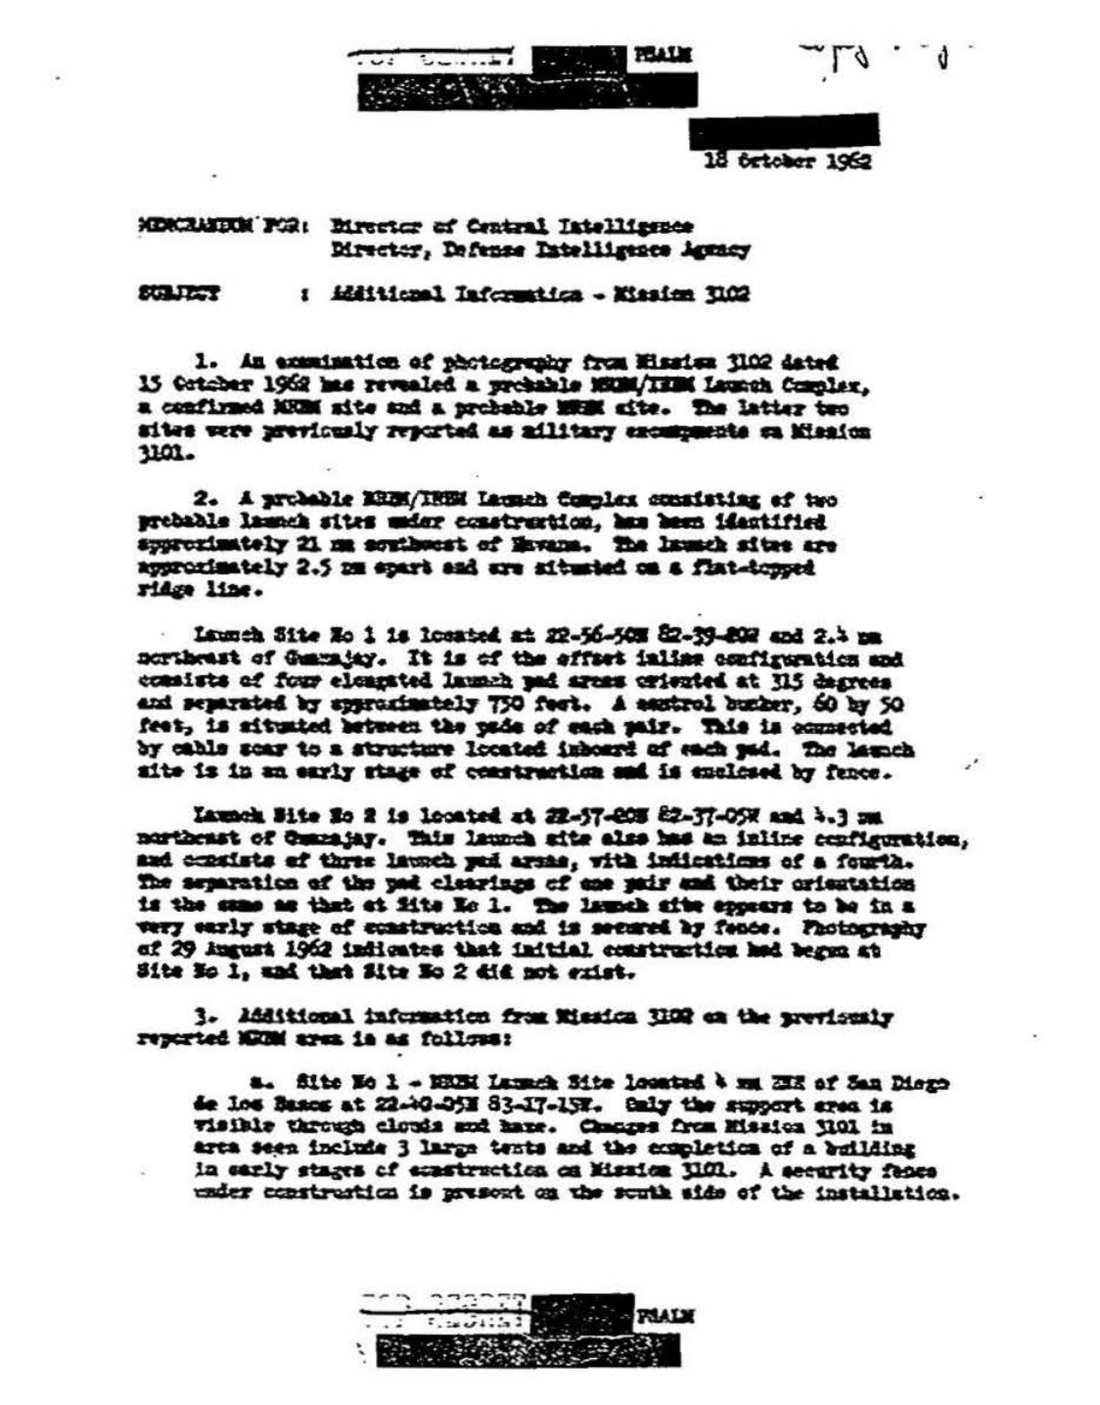

In [4]:
SAMPLES = {
    # scanned 20th-c. typewritten documents (the common student case)
    "cuban_clean":    os.path.join(SAMPLES_DIR, "cuban_missile.jpg"),
    "cuban_degraded": os.path.join(SAMPLES_DIR, "cuban_missile2.jpg"),
    "typescript":     os.path.join(SAMPLES_DIR, "typescript_1961_letter.jpg"),
    "printed_table":  os.path.join(SAMPLES_DIR, "printed_table_pike.jpg"),
    # handwriting / historical scripts (the hard case)
    "declaration":    os.path.join(SAMPLES_DIR, "declaration_1776.jpg"),
    "gettysburg":     os.path.join(SAMPLES_DIR, "gettysburg_handwritten.jpg"),
    "census":         os.path.join(SAMPLES_DIR, "census_1940_table.jpg"),
}

# Take a look at one. (In a notebook, the last expression displays inline.)
Image.open(SAMPLES["cuban_degraded"])

## A clean-print control case


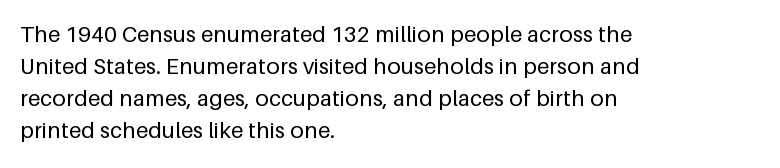

In [5]:
from PIL import ImageDraw, ImageFont
import textwrap

def render_clean_page(paragraph, width=780):
    """Render a paragraph as a clean black-on-white printed page (a PNG)."""
    font = ImageFont.load_default(size=22)  # Pillow's scalable default font
    lines = textwrap.wrap(paragraph, 60)
    img = Image.new("RGB", (width, 40 + 32 * len(lines)), "white")
    draw = ImageDraw.Draw(img)
    for i, line in enumerate(lines):
        draw.text((20, 20 + 32 * i), line, fill="black", font=font)
    return img

clean_text = (
    "The 1940 Census enumerated 132 million people across the United States. "
    "Enumerators visited households in person and recorded names, ages, "
    "occupations, and places of birth on printed schedules like this one."
)
clean_page = render_clean_page(clean_text)
clean_page.save(os.path.join(OUTPUTS_DIR, "clean_page.png"))
clean_page

## Path 1: Tesseract

Tesseract is easy and fast, but limited.

In [6]:
import pytesseract

def ocr_tesseract(image):
    """OCR with Tesseract. Accepts a PIL image or a path; returns plain text."""
    if isinstance(image, str):
        image = Image.open(image)
    return pytesseract.image_to_string(image)

print("--- Tesseract on the clean printed page ---")
print(ocr_tesseract(clean_page).strip())

--- Tesseract on the clean printed page ---
The 1940 Census enumerated 132 million people across the
United States. Enumerators visited households in person and
recorded names, ages, occupations, and places of birth on
printed schedules like this one.


## Scanned 20th-century typewritten documents


Start with the cleaner one (`cuban_clean`). Tesseract does okay:

In [7]:
print(textwrap.fill(" ".join(ocr_tesseract(SAMPLES["cuban_clean"]).split())[:600], 90))

I. Il, wi TOR-SHERET QP 21 Oct 62 SOVIET MILITARY BUILD-UP IN CUBA Now clear to US that
Khrushchev last spring made foreign policy decision on Cuba which involved unprecedented
risks and which made it undeniable that Soviets are playing for very high stakes indeed,
A. The two A. Soviets believed decisive action necessary because: 1, Cuban economy was
deteriorating; 2. There seemed to be mounting pressure in the US for intervention, Soviets
also saw opportunity to: 1, Demonstrate that the US can no longer prevent advance of
Soviet offensive power even in its own hemisphere; 2. Significantly exp


In [8]:
print(textwrap.fill(" ".join(ocr_tesseract(SAMPLES["cuban_degraded"]).split())[:600], 90))



AERAMTAM FOR: 4Bireetcr of Central Istelligesce DMirectsr, Infense Intelligence Jgeacy ait
1 S€€tticoel Infcrmstica ~ Mission Ti02 1. Am examination of pictceraphy from Missiee 3102
dated 25 Cotcber 1962 mee revealed 2 provable IUM/TEIN Launch Complex, @ confirmed MUM
site sof a prebeble MEM cite. The letier teo wites vere previcusly reported as ailitary
excumpmentes ca Kisalcn um. aporctimately 2.5 om spars end are siteucted ca 6 flat-topped
ridge line. Lewnch Site Zo 1 16 losated wt 22-56-50m &2-39-202 and 2.3 oe


## Where Tesseract fails


In [9]:
for name in ["declaration", "gettysburg", "census", "printed_table"]:
    text = " ".join(ocr_tesseract(SAMPLES[name]).split())
    print(f"\n--- Tesseract on {name} ---")
    print(textwrap.fill(text[:350], 90) if text.strip() else "[empty — extracted nothing]")


--- Tesseract on declaration ---
In CONGRESS... uw 4, ye Che wrarimons Declaratiort oe saer wun States of Mnrerica, Ybor an
biel y ng Mic feiss oflie cal: Myf fecnil deckive the cafes which sinft Iam lobie ff wile
ciitn unalienable Reghls, Makameny breve we Lyi fe yy birman evens armas neeeauy fo
oncfraplhto deol Mepitiical banda whith have comme Mam. with-anelhe, and de be which

--- Tesseract on gettysburg ---
Executive Mansion, Washington, 180. Haws pea anc peer! yours aga eres fothen Grange love,
fon in COMED, 00 Renr hOKiort Conceal ww bebe, Ont Kerbreetacy t bho proffer tes Lig. "GLO
row Gro Cento oypab” i Mow tre tae porgzepectd. foe ow poet Cin cee Tinta wrkether Kee
(notion, ov Gang (hein 20 Coreen Orn 20 ceclralcl caw bong pocteca, es mecipaent o

--- Tesseract on census ---
ren ecg Dee reac PAE FS ES ATE EATERS DEPARTAT OF : 2 \ tet ‘DUREAU OF THX CRU ao ne
Matemrscstr \s 9 a : SIXTEENTH CENSUS OF THE UNITED STATES: 1940 emmy wliblag she
POPULATION SCHEDULE

--- Tesseract o

Note the `printed_table` result especially

## Path 2: a vision-language model

Same idea, different engine: hand the image to a VLM and *ask* it to
transcribe. There's no OCR-specific API — it's the `chat_image()` from Lab 6
with an OCR instruction as the prompt. The prompt matters: tell it to
transcribe verbatim and to not "helpfully" modernize spelling or fill gaps.

The default here is `google/gemma-4-26b-a4b-it`. It's cheap (~$0.12/$0.35 per
million tokens), reads handwriting and degraded scans well, and I've had good
luck with it for OCR specifically. It runs on the same OpenRouter key you've
used all week. Nothing about the lab is tied to it: swap the `model=` argument
for the course's `qwen/qwen3-vl-30b-a3b-instruct`, or up to a Gemini 3 Flash
(which tops the OCR leaderboards in 2026 — check openrouter.ai/models for the
current ID); the code doesn't change, only the accuracy and the bill.

In [10]:
OCR_PROMPT = (
    "Transcribe all the text in this document image exactly as it appears. "
    "Preserve the original spelling, punctuation, capitalization, and line "
    "breaks. Do not modernize, correct, summarize, or add commentary. If a word "
    "is illegible, write [illegible]. Output only the transcription."
)

OCR_MODEL = "google/gemma-4-26b-a4b-it"

def ocr_vlm(image_path, model=OCR_MODEL):
    """OCR with a vision-language model through OpenRouter."""
    return chat_image(OCR_PROMPT, image_path, model=model)

# The Gettysburg Address, in Lincoln's handwriting — where Tesseract produced
# noise. (This makes a live API call; needs your OpenRouter key.)
print(ocr_vlm(SAMPLES["gettysburg"]))

Paste your OpenRouter API key: ··········
Executive Mansion,
Washington, 186
Four score and seven years ago our fathers brought
forth, upon this Continent, a new nation, conceived
in liberty, and dedicated to the proposition that
"all men are created equal"
Now we are engaged in a great civil war, testing
whether that nation, or any nation so conceived,
and so dedicated, can long endure. We are met on
a great battle field of that war. We have
come to dedicate a portion of it, as a final rest-
ing place for those who here died that the nation
might live. It is altogether fitting and proper that we should do this. But, in a
larger sense, we can not dedicate -- we can not
consecrate -- we can not hallow -- this ground.
The brave men, living and dead, who struggled
here, have hallowed it, far above our poor power
to add or detract. The world will little note, nor long
remember what we say here; whilst it can never
forget what they did here.
It is rather for us, the living, to be dedicated 

That should be readable English where Tesseract gave you scrambled fragments.
The VLM isn't matching letter shapes one at a time; it's reading the way you
do, using the sentence so far to resolve each smudged word. That's also its
failure mode, which we get to below: a model that guesses from context will
sometimes guess *wrong* and hand you a fluent, confident transcription of
words that aren't on the page.

The same context-reading rescues the degraded Cuban memo, where Tesseract gave
us "AERAMEAM FOR". Run it through the VLM:

In [11]:
cuban_vlm = ocr_vlm(SAMPLES["cuban_degraded"])
print(cuban_vlm[:700])

TOP SECRET

18 October 1962

MEMORANDUM FOR: Director of Central Intelligence
Director, Defense Intelligence Agency

SUBJECT: Additional Information - Mission 3102

1. An examination of photography from Mission 3102 dated
15 October 1962 has revealed a probable MRBM/IRBM Launch Complex,
a confirmed MRBM site and a probable IRBM site. The latter two
sites were previously reported as military encampments on Mission
3101.

2. A probable MRBM/IRBM Launch Complex consisting of two
probable launch sites under construction, has been identified
approximately 21 km northeast of Mvane. The launch sites are
approximately 2.5 km apart and are situated on a flat-topped
ridge line.

Launch Site No 1 is lo


"MEMORANDUM FOR: Director of Central Intelligence", clean
paragraph numbers, readable prose, `[illegible]` where the redaction bars are.
But this is exactly the document to be suspicious of, and it's worth stopping
on *why*. On a faint intelligence memo the hard-to-read tokens are the ones
that carry the information: place names, compass directions, map coordinates,
unit designations. Those have little linguistic context for the model to lean
on, so they're where it quietly guesses. In my dev run the memo's "21 km
southeast of Havana" came back as "21 km northeast of Mavane" — a wrong
direction *and* a city that doesn't exist, in a sentence that otherwise reads
perfectly. (It did get the missile designators MRBM/IRBM right, which the
course's qwen model garbled — so which fields break depends on the model, and
you don't know in advance which.)

That's the whole hallucination lesson in one document: the VLM is dramatically
better on average *and* silently wrong on the specific fields you'd build a
dataset from. Read the geography and numbers back against the image; don't
trust the fluency. (Your exact run may differ — the model isn't perfectly
deterministic — but the *kind* of error, degraded names/directions/numbers, is
the one to watch for.)

## Seeing the gap side by side

In [ ]:
for name, path in SAMPLES.items():
    tess = " ".join(ocr_tesseract(path).split())
    vlm  = " ".join(ocr_vlm(path).split())
    print("=" * 92)
    print(name.upper())
    print("-" * 92)
    print("TESSERACT:", (textwrap.fill(tess[:200], 90) if tess.strip() else "[empty]"))
    print("VLM:      ", textwrap.fill(vlm[:200], 90))

CUBAN_CLEAN
--------------------------------------------------------------------------------------------
TESSERACT: I. Il, wi TOR-SHERET QP 21 Oct 62 SOVIET MILITARY BUILD-UP IN CUBA Now clear to US that
Khrushchev last spring made foreign policy decision on Cuba which involved unprecedented
risks and which made it
VLM:       TOP SECRET 0, 21 Oct 62 SOVIET MILITARY BUILD-UP IN CUBA I. Now clear to US that
Khrushchev last spring made foreign policy decision on Cuba which involved unprecedented
risks and which made it undeni
CUBAN_DEGRADED
--------------------------------------------------------------------------------------------
TESSERACT: AERAMTAM FOR: 4Bireetcr of Central Istelligesce DMirectsr, Infense Intelligence Jgeacy ait
1 S€€tticoel Infcrmstica ~ Mission Ti02 1. Am examination of pictceraphy from Missiee 3102
dated 25 Cotcber 1
VLM:       MEMORANDUM FOR: Director of Central Intelligence Director, Defense Intelligence Agency
SUBJECT: Additional Information - Mission 3102 1. An 

## What does a page cost?

In [ ]:
import pandas as pd

log = pd.read_csv(course_utils.LOG_PATH)
vlm_calls = log[log["model"] == OCR_MODEL]
if len(vlm_calls):
    avg_in  = vlm_calls["input_tokens"].mean()
    avg_out = vlm_calls["output_tokens"].mean()
    avg_cost = vlm_calls["cost_usd"].astype(float).mean()
    print(f"Per page, measured over {len(vlm_calls)} VLM calls:")
    print(f"  input tokens ~ {avg_in:,.0f}   output tokens ~ {avg_out:,.0f}")
    print(f"  cost/page    ~ ${avg_cost:.5f}")
    print(f"  1,000 pages  ~ ${avg_cost * 1_000:,.2f}")
    print(f"  100,000 pages~ ${avg_cost * 100_000:,.2f}")
    print("\nTesseract, the same job: $0.00 (but it couldn't read most of them).")



##  OCR into *structured* data


In [ ]:
PRINTED_TABLE_PROMPT = (
    "This is a printed 1870 census table of population by precinct. Extract every "
    "data row (not the TOTAL row) as JSON with this exact shape:\n"
    '{"rows": [{"precinct": "...", "voters": null, "population": null, '
    '"natives": null, "foreign": null, "white": null, "colored": null}]}\n'
    "Use numbers for the numeric fields, or null for a blank/unreadable cell. "
    "Return only the JSON."
)

raw = chat_image(PRINTED_TABLE_PROMPT, SAMPLES["printed_table"], model=OCR_MODEL)
table = parse_json(raw, required_keys=["rows"])

if table:
    df = pd.DataFrame(table["rows"])
    print(df.to_string(index=False))
    # Does our extracted column sum match the printed total?
    got = pd.to_numeric(df.get("voters"), errors="coerce").sum()
    print(f"\nExtracted voters sum: {got:.0f}   Printed TOTAL: 4971   "
          f"{'MATCH' if got == 4971 else 'MISMATCH -- so at least one cell is misread'}")
else:
    print("Parse failed — the raw response was:\n", raw[:500])



In [ ]:
CENSUS_PROMPT = (
    "This is a page from the 1940 U.S. Census population schedule. Read the "
    "handwritten rows and return the first 5 people as JSON. Use this exact "
    "shape:\n"
    '{"people": [{"name": "...", "age": "...", "sex": "...", '
    '"birthplace": "...", "occupation": "..."}]}\n'
    "Transcribe what's written; use \"\" for a field you can't read. "
    "Return only the JSON."
)

raw = chat_image(CENSUS_PROMPT, SAMPLES["census"], model=OCR_MODEL)
census = parse_json(raw, required_keys=["people"])
print(pd.DataFrame(census["people"]).to_string(index=False) if census
      else f"Parse failed:\n{raw[:500]}")

Hallucination warning!

## Try it on your own documents

Upload a scan, a photo of a page, or a screenshot — something from your own
research if you have it — and run both tools on it.

In [ ]:
if IN_COLAB:
    from google.colab import files
    uploaded = files.upload()
    my_doc = os.path.join(OUTPUTS_DIR, next(iter(uploaded)))
    with open(my_doc, "wb") as f:
        f.write(next(iter(uploaded.values())))
else:
    # Local: point this at any image file on disk. Default to the handwritten
    # 1854 Lincoln letter that also ships in ocr_samples/.
    my_doc = os.path.join(SAMPLES_DIR, "lincoln_letter_handwritten.jpg")

print("Image:", my_doc, "\n")
print("--- Tesseract ---")
print(" ".join(ocr_tesseract(my_doc).split())[:400] or "[empty]")
print("\n--- VLM ---")
print(ocr_vlm(my_doc)[:400])